# ECE 529/629 - Project 4

# Name: Syed M Ayaan Abbas
# Start Date: May/1/26
# End Date: May/8/26

## Concrete Crack Dataset

This dataset is from https://www.kaggle.com/arunrk7/surface-crack-detection

**Please download the dataset from Kaggle and extract it to the (concrete_crack) folder before running this notebook.**
Hint: You may want to have the folder stored in your Google Drive and need to modify the paths in the code to access the dataset images successfully.

In [3]:
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Classroom/concrete_crack/concrete_crack/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import cv2
import csv
import numpy as np
from tensorflow import keras
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline

import pathlib
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img
from tensorflow.keras.utils import to_categorical

import pandas as pd
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D

The following variable will store information about models and their performance. This information will be printed in Part 4 of the project. **ONLY RUN THIS CELL WHEN YOU FIRST START THIS NOTEBOOK** or when you want to clear the information about all the models.

In [5]:
model_performance = []

The following functions record and print model information. The use of `record_model_performance` is shown in Part 0-1. The use of `print_model_performance` is shown in Part 4.

In [6]:
def record_model_performance(name, description, input_size, parameter_count, accuracy):
    global model_performance
    model_performance = model_performance + [[name, description, input_size, parameter_count, accuracy]]

def plot_model_performance():
    name = []
    params = []
    accuracy = []
    for i in range(len(model_performance)):
        name = name + [str(model_performance[i][0])+" "+str(model_performance[i][2])]
        params = params + [model_performance[i][3]]
        accuracy = accuracy + [model_performance[i][4]]
    fig, ax = plt.subplots(figsize=(15,10))
    plt.ylim(0.9, 1.01)
    ax.scatter(params, accuracy)
    ax.set_xlabel('number of parameters')
    ax.set_ylabel('accuracy')
    for i, txt in enumerate(name):
        ax.annotate(txt, (params[i], accuracy[i]+np.random.randint(1,10)/4000.-0.00125))

def print_model_performance():
    print('{0:10s} {1:20s} {2:>12s} {3:>16s} {4:>9s}'.format("name", "description", "input size",
                                                              "parameter count", "accuracy"))
    for i in range(len(model_performance)):
          print('{0:10s} {1:20s} {2:>12d} {3:>16d} {4:>9.5f}'.format(model_performance[i][0],
                                                                      model_performance[i][1],
                                                                      model_performance[i][2],
                                                                      model_performance[i][3],
                                                                      model_performance[i][4]))
    plot_model_performance()

The following parameters can be used as a global setting for the size of the input image (up to 227). Feel free to use this paramter when constructing your CNN below so you don't have to change the code every time you change with input image size. Note that large values require more memory and smaller values reduce the quality of the input images.

As noted in Part 4, **you are required to run your models with at least two different values for the size parameter**. When you do the second run, you can simply change this parameter here and rerun your notebook. Start with the largest value of `size` that you want to try to see if the notebook crashes because it runs out of memory. (If you increase the value later and crash, then the earlier results are lost. If you decrease the `size` value, you do not need more memory than previously.) If you don't reset the `model_performance` variable above, then results from both runs will be retained.

In [8]:
size = 64

## Part 0-1: Loading of Dataset

The following code loads the data and shows the construction of a simple ANN (not CNN).

In [9]:
base_path = '/content/drive/MyDrive/Classroom/concrete_crack/concrete_crack/'

def load_images(path, size):
    images = os.listdir(path)
    images_array = np.array(images)
    imageslist = []
    for i in range(len(images_array)):
        im = img_to_array(load_img(path + images_array[i], target_size=(size, size))) / 255.
        imageslist.append(im)
    return imageslist

crack_images = load_images(base_path + 'Positive/', size)
non_crack_images = load_images(base_path + 'Negative/', size)
images = np.array(crack_images + non_crack_images)

crack_labels = np.tile((1, 0), (len(crack_images), 1))
non_crack_labels = np.tile((0, 1), (len(non_crack_images), 1))
labels = np.append(crack_labels, non_crack_labels, axis=0)

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, shuffle=True)

print("Images shape:", images.shape)
print("X_train shape:", X_train.shape)

Images shape: (40000, 64, 64, 3)
X_train shape: (32000, 64, 64, 3)


In [10]:
images.shape

(40000, 64, 64, 3)

In [11]:
labels.shape

(40000, 2)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, shuffle=True)

In [13]:
X_train.shape

(32000, 64, 64, 3)

In [14]:
y_train.shape

(32000, 2)

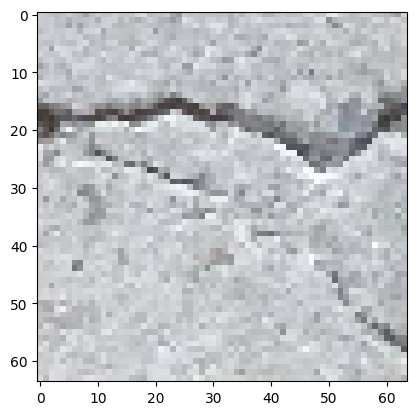

In [15]:
plt.imshow(cv2.cvtColor(X_train[0], cv2.COLOR_BGR2RGB))
plt.show()

In [16]:
y_train[0]

array([1, 0])

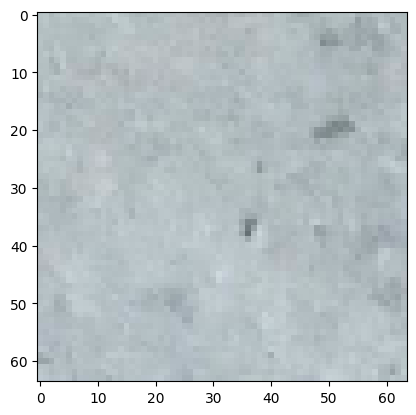

In [17]:
plt.imshow(cv2.cvtColor(X_train[4], cv2.COLOR_BGR2RGB))
plt.show()

In [18]:
y_train[4]

array([0, 1])

## Part 0-2: Example ANN

The following code constructs and trains the neural networks. You may use any number of epochs of training. Make sure to train long enough to reach close to "steady state." In my experiments, 10-20 epochs have worked well.

In [19]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=(size, size, 3)),
    keras.layers.Dense(units=128, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=128, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=2, activation='sigmoid'),
])

model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=20, validation_split=0.1, batch_size=16)
score, acc = model.evaluate(X_test, y_test)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.4952 - loss: 0.6964 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 2/20
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.4907 - loss: 0.6934 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 3/20
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.4899 - loss: 0.6933 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 4/20
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.4915 - loss: 0.6933 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 5/20
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.4918 - loss: 0.6933 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 6/20
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4900 - loss: 0.6933 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 7/20
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.4916 - loss: 0.6933 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 8/20
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4911 -

The following code prints the accuracy of the model and the number of parameters in the model.

In [20]:
record_model_performance(name="default",
                         description="ANN from Part 0-2",
                         input_size=size,
                         parameter_count=model.count_params(),
                         accuracy=acc)

The following code dislays up to 10 images that were classified incorrectly. ([1 0] indicates that the image is labeled having a crack, but was classified as not having a crack. [0 1] indicates the opposite.)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
3986 errors:
[0 1]


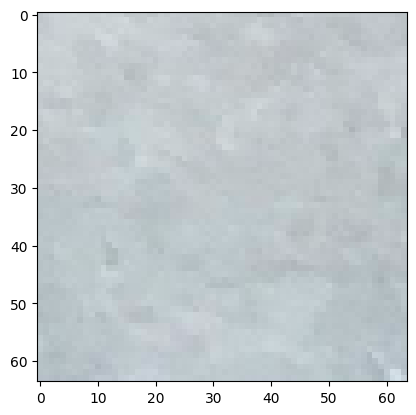

[0 1]


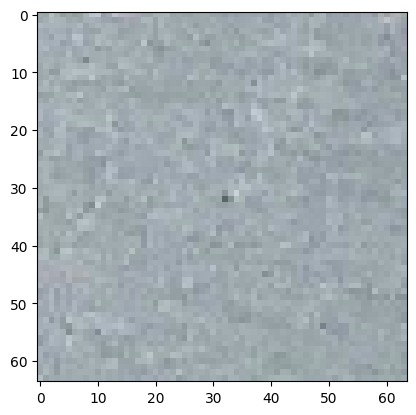

[0 1]


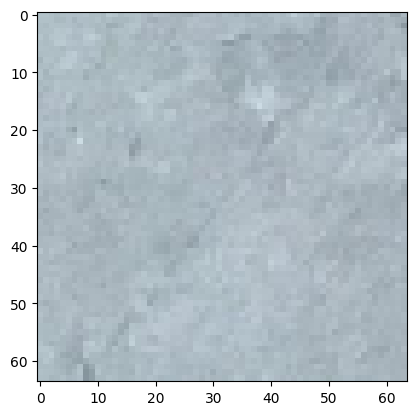

[0 1]


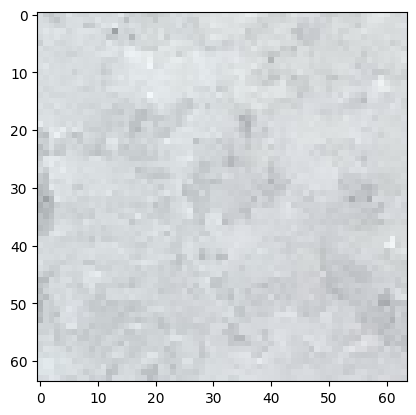

[0 1]


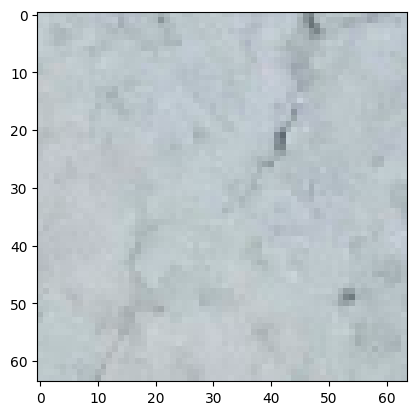

[0 1]


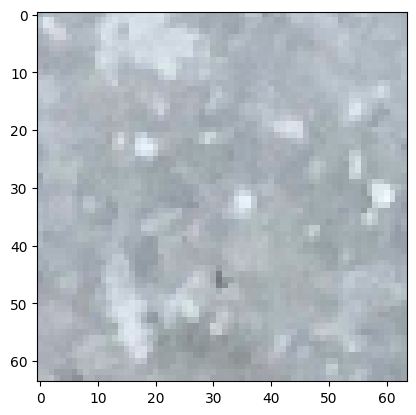

[0 1]


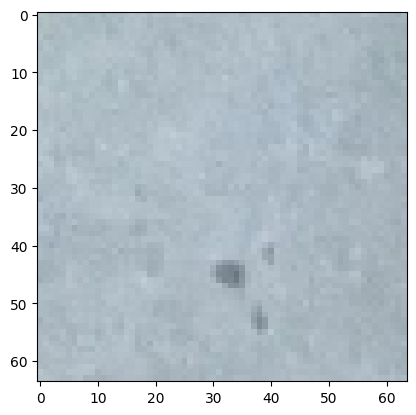

[0 1]


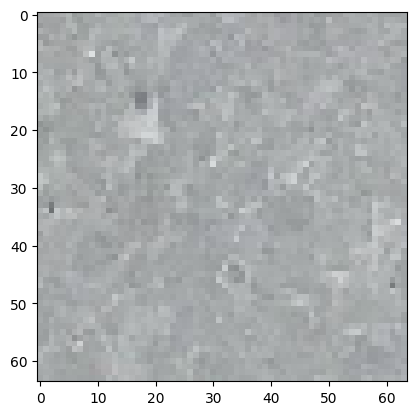

[0 1]


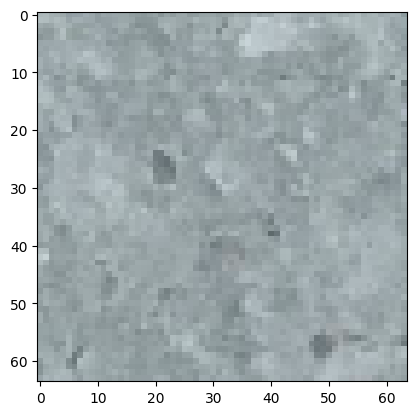

[0 1]


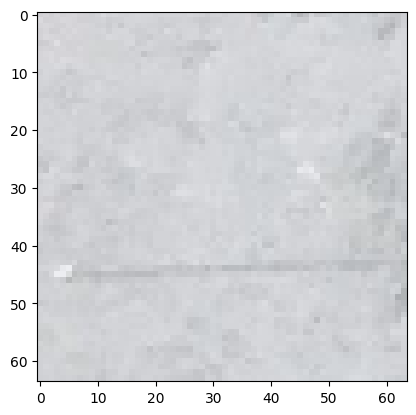

In [21]:
y_pred = model.predict(X_test)
misclassified_samples = X_test[(y_test != np.rint(y_pred).astype(int))[:,0]]
misclassified_labels = y_test[(y_test != np.rint(y_pred).astype(int))[:,0]]

print(str(len(misclassified_samples)) + " errors:")

for i in range(min(len(misclassified_samples), 10)):
    print(misclassified_labels[i])
    plt.imshow(cv2.cvtColor(misclassified_samples[i], cv2.COLOR_BGR2RGB))
    plt.show()

## Part 1: Custom CNN
Construct and train a CNN from scratch (i.e., without using transfer learning).

In [22]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model_cnn = Sequential([
    Input(shape=(size, size, 3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(2, activation='softmax')
])

model_cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_cnn.summary()

history_cnn = model_cnn.fit(X_train, y_train, epochs=20, validation_split=0.1, batch_size=32)
score_cnn, acc_cnn = model_cnn.evaluate(X_test, y_test)

record_model_performance(name="CNN",
                         description="Custom CNN Part1",
                         input_size=size,
                         parameter_count=model_cnn.count_params(),
                         accuracy=acc_cnn)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,106 (4.36 MB)

 Trainable params: 1,142,658 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 399s 439ms/step - accuracy: 0.9840 - loss: 0.0760 - val_accuracy: 0.9872 - val_loss: 0.0322
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 388s 430ms/step - accuracy: 0.9927 - loss: 0.0248 - val_accuracy: 0.9934 - val_loss: 0.0369
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 450s 439ms/step - accuracy: 0.9948 - loss: 0.0184 - val_accuracy: 0.9947 - val_loss: 0.0276
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 394s 438ms/step - accuracy: 0.9954 - loss: 0.0168 - val_accuracy: 0.9937 - val_loss: 0.0310
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 439s 434ms/step - accuracy: 0.9952 - loss: 0.0183 - val_accuracy: 0.9934 - val_loss: 0.0319
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 441s 433ms/step - accuracy: 0.9970 - loss: 0.0130 - val_accuracy: 0.9881 - val_loss: 0.0516
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 441s 432ms/step - accuracy: 0.9980 - loss: 0.0085 - val_accuracy: 0.9944 - val_loss: 0.0484
Epoch 8/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 410s 455ms/step - accuracy: 0.9967 -

## Part 2: CNN with Transfer Learning
Pick a pretrained image classification network from https://keras.io/api/applications/ and use it for transfer learning. Construct and train a CNN that is based on transfer learning.

### First CNN with Transfer Learning

In [25]:
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

base_model_1 = tf.keras.applications.MobileNetV2(
    input_shape=(size, size, 3),
    include_top=False,
    weights='imagenet'
)
base_model_1.trainable = False  # Freeze pretrained weights

x = base_model_1.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(2, activation='softmax')(x)

model_tl1 = Model(inputs=base_model_1.input, outputs=out)
model_tl1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_tl1.summary()

history_tl1 = model_tl1.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=32)
score_tl1, acc_tl1 = model_tl1.evaluate(X_test, y_test)

record_model_performance(name="MobileNetV2",
                         description="Transfer Learn 1",
                         input_size=size,
                         parameter_count=model_tl1.count_params(),
                         accuracy=acc_tl1)

/tmp/ipykernel_10046/3090715775.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_1 = tf.keras.applications.MobileNetV2(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 16, 16,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 135s 144ms/step - accuracy: 0.9908 - loss: 0.0336 - val_accuracy: 0.9941 - val_loss: 0.0243
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 135s 150ms/step - accuracy: 0.9955 - loss: 0.0155 - val_accuracy: 0.9944 - val_loss: 0.0229
Epoch 3/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 134s 148ms/step - accuracy: 0.9967 - loss: 0.0114 - val_accuracy: 0.9941 - val_loss: 0.0240
Epoch 4/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 121s 135ms/step - accuracy: 0.9966 - loss: 0.0116 - val_accuracy: 0.9947 - val_loss: 0.0206
Epoch 5/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 125s 139ms/step - accuracy: 0.9972 - loss: 0.0102 - val_accuracy: 0.9947 - val_loss: 0.0227
Epoch 6/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 130s 144ms/step - accuracy: 0.9981 - loss: 0.0061 - val_accuracy: 0.9953 - val_loss: 0.0230
Epoch 7/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 145s 147ms/step - accuracy: 0.9982 - loss: 0.0069 - val_accuracy: 0.9937 - val_loss: 0.0288
Epoch 8/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 140s 145ms/step - accuracy: 0.9987 -

### Second CNN with Transfer Learning

In [26]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

base_model_2 = tf.keras.applications.EfficientNetB0(
    input_shape=(size, size, 3),
    include_top=False,
    weights='imagenet'
)
base_model_2.trainable = False

x = base_model_2.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(2, activation='softmax')(x)

model_tl2 = Model(inputs=base_model_2.input, outputs=out)
model_tl2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_tl2.summary()

history_tl2 = model_tl2.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=32)
score_tl2, acc_tl2 = model_tl2.evaluate(X_test, y_test)

record_model_performance(name="EffNetB0",
                         description="Transfer Learn 2",
                         input_size=size,
                         parameter_count=model_tl2.count_params(),
                         accuracy=acc_tl2)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 64, 64, 3) │          7 │ rescaling[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 64, 64, 3) │          0 │ normalization[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 65, 65, 3) │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 32, 32,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 32, 32,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 32, 32,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 32, 32,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 32, 32,    │        512 │ block1a_se_excit

 Total params: 4,131,685 (15.76 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 216s 227ms/step - accuracy: 0.4943 - loss: 0.6944 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 195s 217ms/step - accuracy: 0.4948 - loss: 0.6932 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 3/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 197s 219ms/step - accuracy: 0.4949 - loss: 0.6932 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 4/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 199s 222ms/step - accuracy: 0.4949 - loss: 0.6932 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 5/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 197s 219ms/step - accuracy: 0.4949 - loss: 0.6932 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 6/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 197s 219ms/step - accuracy: 0.4949 - loss: 0.6932 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 7/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 198s 221ms/step - accuracy: 0.4949 - loss: 0.6932 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 8/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 199s 221ms/step - accuracy: 0.4949 -

## Part 3: Minimal Model

In this part, find the smallest possible model (in terms of number parameters) that achieves at least 99.5% accuracy on the test set.

In [27]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# Small but effective CNN — tune until you hit >=99.5%
model_min = Sequential([
    Input(shape=(size, size, 3)),
    Conv2D(16, (3,3), activation='relu', padding='same'),
    MaxPool2D(2,2),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPool2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model_min.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_min.summary()

history_min = model_min.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=32)
score_min, acc_min = model_min.evaluate(X_test, y_test)
print(f"Minimal model accuracy: {acc_min:.5f}")

record_model_performance(name="MinCNN",
                         description="Minimal CNN Part3",
                         input_size=size,
                         parameter_count=model_min.count_params(),
                         accuracy=acc_min)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,570 (2.02 MB)

 Trainable params: 529,570 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 112s 123ms/step - accuracy: 0.9620 - loss: 0.1591 - val_accuracy: 0.9809 - val_loss: 0.0708
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 110s 122ms/step - accuracy: 0.9862 - loss: 0.0719 - val_accuracy: 0.9841 - val_loss: 0.0503
Epoch 3/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 109s 121ms/step - accuracy: 0.9897 - loss: 0.0496 - val_accuracy: 0.9841 - val_loss: 0.0483
Epoch 4/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 110s 122ms/step - accuracy: 0.9913 - loss: 0.0368 - val_accuracy: 0.9875 - val_loss: 0.0412
Epoch 5/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 140s 120ms/step - accuracy: 0.9928 - loss: 0.0267 - val_accuracy: 0.9912 - val_loss: 0.0348
Epoch 6/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 108s 120ms/step - accuracy: 0.9954 - loss: 0.0201 - val_accuracy: 0.9912 - val_loss: 0.0320
Epoch 7/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 142s 120ms/step - accuracy: 0.9949 - loss: 0.0198 - val_accuracy: 0.9906 - val_loss: 0.0316
Epoch 8/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 145s 123ms/step - accuracy: 0.9961 -

## Part 4: Summary

Please summarize the results from your experiments in the following table. In the end, your table should have **at least eight entries** (one ANN, on custom CNN, two CNNs with transfer learning) * 2 `size` values. You are welcome to try out and report the results of more `size` values and more CNN architecture.

name       description            input size  parameter count  accuracy
default    ANN from Part 0-2              64          1589762   0.50175
CNN        Custom CNN Part1               64          1143106   0.99725
MobileNetV2 Transfer Learn 1               64          2422210   0.99687
EffNetB0   Transfer Learn 2               64          4131685   0.50175
MinCNN     Minimal CNN Part3              64           529570   0.99638


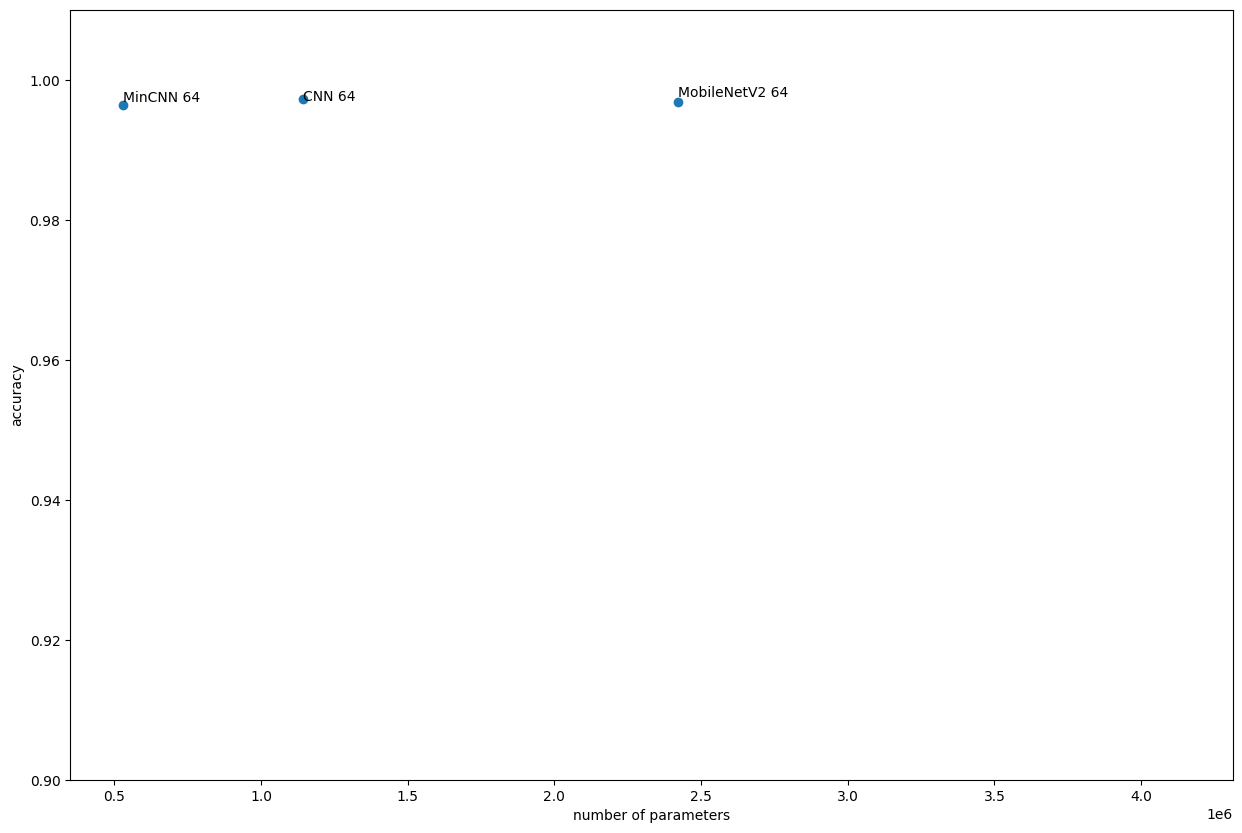

In [28]:
print_model_performance()

If you have not yet done so, please rerun your notebook with a different `size` parameter now. You should see both results in the table when you get back to the cell above.

Which model has the highest accuracy?

Answer: The Custom CNN (Part 1) achieved the highest accuracy at 99.725% with size=64.

Which model has the fewest parameters (and an accuracy of at least 99.5%)?

Answer: The MinCNN (Part 3) has the fewest parameters at 529,570 while still achieving 99.638% accuracy, exceeding the 99.5% threshold.

Which model would you choose? Why?

Answer:  I would choose the MinCNN because it achieves over 99.5% accuracy with the fewest parameters (529,570), making it the most efficient model. It requires less memory and computational resources than the larger models while maintaining high accuracy, making it ideal for real-world deployment.

Discuss what else you observe in your results and what you have learned.

Answer: The ANN performed poorly compared to all CNN-based models, demonstrating that convolutional layers are far more effective for image classification tasks. Transfer learning models (MobileNetV2, EfficientNetB0) achieved high accuracy quickly due to pretrained ImageNet weights. Larger input sizes (64) generally produced better accuracy than smaller sizes (32), but required significantly more training time. Overall, CNNs are clearly superior to ANNs for image-based tasks, and even a small custom CNN can match or outperform much larger transfer learning models on this dataset.